# Machine Learning Lab 5: Linear Regression — Predicting House Prices

## Student Information

- **Name:** Kalpana Bai Ganglani
- **CMS ID:** 023-24-0163
- **Section:** F
- **GitHub:** [Enter Your GitHub Link]
- **Kaggle:** https://www.kaggle.com/kalpanabaiganglani 
- **Dataset:** House Prices — Advanced Regression Techniques
- **Dataset Source:** Kaggle

# Part 1: Dataset, Problem & Feature/Target Identification

In this part, the House Prices dataset is loaded and explored. The problem is identified as a regression problem, and the dependent and independent variables are identified. Numerical and categorical features are also separated before preparing the data for modeling.

## Task 1: Load and Inspect the Dataset

Load the House Prices training dataset and briefly inspect its shape, data types, first few rows, and summary statistics.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv("train.csv")

print("Dataset Shape:", train.shape)

print("\nFirst 5 Rows:")
display(train.head())

print("\nDataset Information:")
train.info()

print("\nSummary Statistics:")
display(train.describe())

Dataset Shape: (1460, 81)

First 5 Rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 1

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Task 1 Interpretation

The training dataset contains 1,460 house records and 81 columns. The dataset contains both numerical and categorical variables. The `info()` and `describe()` outputs provide information about the data types, missing values, and numerical summary statistics.

## Task 2: Identify the Dependent and Independent Variables

The dependent variable is the variable that the model will predict, while the independent variables are the features used to make the prediction.

For this lab, `SalePrice` is the dependent variable. A manageable subset of numerical and categorical features is selected as independent variables.

In [4]:
numerical_features = [
    'GrLivArea',
    'OverallQual',
    'TotalBsmtSF',
    'GarageCars',
    'YearBuilt',
    'FullBath',
    '1stFlrSF',
    'GarageArea',
    'TotRmsAbvGrd'
]

categorical_features = [
    'Neighborhood',
    'HouseStyle',
    'KitchenQual'
]

target = 'SalePrice'

print("Numerical Features:")
for feature in numerical_features:
    print("-", feature)

print("\nCategorical Features:")
for feature in categorical_features:
    print("-", feature)

print("\nDependent Variable:")
print("-", target)

Numerical Features:
- GrLivArea
- OverallQual
- TotalBsmtSF
- GarageCars
- YearBuilt
- FullBath
- 1stFlrSF
- GarageArea
- TotRmsAbvGrd

Categorical Features:
- Neighborhood
- HouseStyle
- KitchenQual

Dependent Variable:
- SalePrice


### Task 2 Interpretation

The selected independent variables contain 9 numerical features and 3 categorical features. The dependent variable is `SalePrice`, which represents the selling price of each house.

## Task 3: Explain Why This is a Regression Problem

This problem must be identified as either a regression or classification problem before building the model.

### Answer

This is a regression problem because the target variable, `SalePrice`, is a continuous numerical value. The model predicts an actual house price rather than assigning a house to a category. Therefore, regression metrics such as MAE, MSE, RMSE, and R² will be used to evaluate the model.

# Part 2: Data Preparation & Train/Test Split

In this part, the selected features are prepared for Linear Regression. Since Linear Regression requires numerical input, categorical variables are converted into numerical form using one-hot encoding. Missing values are handled, and the dataset is divided into training and testing sets.

## Task 4: Prepare X and y and Encode Categorical Features

Create the feature matrix `X` and target variable `y`. The categorical features must be converted into numerical form because scikit-learn's `LinearRegression` model requires numerical input.

One-hot encoding is used for categorical variables because these variables contain multiple categories without a meaningful numerical order.

In [5]:
features = numerical_features + categorical_features

X = train[features].copy()
y = train[target].copy()

print("X Shape before encoding:", X.shape)
print("y Shape:", y.shape)

X = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

print("\nX Shape after encoding:", X.shape)

X Shape before encoding: (1460, 12)
y Shape: (1460,)

X Shape after encoding: (1460, 43)


### Task 4 Interpretation

The categorical variables were converted into numerical columns using one-hot encoding. `drop_first=True` was used to avoid creating redundant dummy variables. The target variable `SalePrice` was kept separate from the feature matrix.

## Task 5: Check for Missing Values and Numeric Data

After encoding the categorical features, the feature matrix must contain only numerical values and no missing values.

In [6]:
print("Missing values before handling:")
print(X.isnull().sum()[X.isnull().sum() > 0])

print("\nNumber of non-numeric columns:")
print(X.select_dtypes(exclude=np.number).shape[1])

Missing values before handling:
Series([], dtype: int64)

Number of non-numeric columns:
0


In [7]:
X = X.fillna(X.median())

In [8]:
print("Total missing values:", X.isnull().sum().sum())
print("Number of non-numeric columns:", X.select_dtypes(exclude=np.number).shape[1])

Total missing values: 0
Number of non-numeric columns: 0


### Task 5 Interpretation

The categorical variables have been converted into numerical columns, so there are no non-numeric feature columns remaining. Missing numerical values were handled using the median of each feature. The final feature matrix therefore contains numerical values without missing values.

## Task 6: Split the Dataset into Training and Testing Sets

The prepared dataset is divided into training and testing sets using an 80/20 split. The training data is used to train the Linear Regression model, while the testing data is used to evaluate its performance on unseen data.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1168, 43)
X_test shape: (292, 43)
y_train shape: (1168,)
y_test shape: (292,)


### Task 6 Interpretation

The dataset was divided into 80% training data and 20% testing data. The training set will be used to fit the Linear Regression model, while the testing set will be used to measure how well the model performs on unseen houses.

# Part 3: Linear Regression & Predictions

In this part, a Multiple Linear Regression model is trained using the prepared training data. The trained model is then used to predict house prices for the test dataset. The actual and predicted prices are compared for a sample of 10 test houses.

## Task 7: Train the Linear Regression Model

A Multiple Linear Regression model is trained using the prepared training data. The feature matrix `X_train` contains the selected house features, while `y_train` contains the actual `SalePrice` values.


In [10]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Task 7 Interpretation

The Multiple Linear Regression model was successfully trained using the training dataset. The model learned the relationship between the selected house features and `SalePrice`.

## Task 8: Generate Predictions and Compare Actual vs. Predicted Prices

The trained Linear Regression model is used to predict the prices of houses in the test set. The actual and predicted prices are displayed for 10 test houses to observe how closely the model's predictions match the actual values.

In [ ]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,154500,139611.763086
1,325000,324212.785705
2,115000,112785.606071
3,159000,175375.682745
4,315500,316134.680461
5,75500,66674.419182
6,311500,235741.486086
7,146000,145564.516601
8,84500,66246.749181
9,135500,120464.104839


### Task 8 Interpretation

The model generated predicted prices for the test houses. The comparison table shows the actual `SalePrice` values alongside the prices predicted by the Linear Regression model. Differences between the actual and predicted values represent prediction errors that will be analyzed further using residuals and regression metrics in Part 5.

In [12]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison['Difference'] = (
    comparison['Actual Price'] - comparison['Predicted Price']
)

comparison.head(10)

,Actual Price,Predicted Price,Difference
0,154500,139611.763086,14888.236914
1,325000,324212.785705,787.214295
2,115000,112785.606071,2214.393929
3,159000,175375.682745,-16375.682745
4,315500,316134.680461,-634.680461
5,75500,66674.419182,8825.580818
6,311500,235741.486086,75758.513914
7,146000,145564.516601,435.483399
8,84500,66246.749181,18253.250819
9,135500,120464.104839,15035.895161


### Part 3 Conclusion

In this part, a Multiple Linear Regression model was trained using the prepared training data. The trained model was used to predict house prices in the test set. A comparison of actual and predicted prices was created for 10 test houses. The model's numerical performance will be evaluated using regression metrics in the following parts.

# Part 4: Coefficients & Intercept

In this part, the coefficients and intercept of the trained Linear Regression model are extracted and interpreted. Each coefficient shows the estimated change in `SalePrice` associated with a one-unit change in a feature while keeping the other features constant.

## Task 9: Extract Coefficients and Interpret Them

The trained Linear Regression model contains an intercept and one coefficient for every encoded feature. A coefficient table is created to show each feature, its coefficient, and its interpretation in plain English.

For numerical features, the coefficient represents the estimated change in `SalePrice` for a one-unit increase in that feature, while keeping other features constant.

For encoded categorical features, the coefficient represents the estimated difference in `SalePrice` compared with the omitted reference category, while keeping other features constant.

In [ ]:
intercept = model.intercept_
coefficients = model.coef_
coefficient_table = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': coefficients
})

def interpret_coefficient(row):
    feature = row['Feature']
    coefficient = row['Coefficient']
    
    if coefficient >= 0:
        direction = "increase"
    else:
        direction = "decrease"
    
    return (
        f"Holding other features constant, a one-unit increase in "
        f"{feature} is associated with an estimated {direction} of "
        f"{abs(coefficient):.2f} in SalePrice."
    )

coefficient_table['Interpretation'] = coefficient_table.apply(
    interpret_coefficient,
    axis=1
)

print("Intercept:", intercept)

display(coefficient_table)

Intercept: -419970.98613932135


,Feature,Coefficient,Interpretation
0,GrLivArea,66.044767,"Holding other features constant, a one-unit in..."
1,OverallQual,13104.207968,"Holding other features constant, a one-unit in..."
2,TotalBsmtSF,11.953296,"Holding other features constant, a one-unit in..."
3,GarageCars,9416.205513,"Holding other features constant, a one-unit in..."
4,YearBuilt,213.835000,"Holding other features constant, a one-unit in..."
5,FullBath,-640.620632,"Holding other features constant, a one-unit in..."
6,1stFlrSF,-23.647367,"Holding other features constant, a one-unit in..."
7,GarageArea,8.189418,"Holding other features constant, a one-unit in..."
8,TotRmsAbvGrd,1566.830843,"Holding other features constant, a one-unit in..."
9,Neighborhood_Blueste,3610.036300,"Holding other features constant, a one-unit in..."


### Task 9 Interpretation

The coefficient table shows the estimated relationship between each selected feature and `SalePrice`. Positive coefficients indicate that higher values of a feature are associated with higher predicted house prices, while negative coefficients indicate an association with lower predicted prices, when other features are held constant. The categorical variables appear as separate one-hot encoded features.

## Task 10: Interpret the Intercept

The intercept represents the predicted `SalePrice` when all input features have a value of zero.

### Answer

The intercept does not have a very sensible real-world interpretation for this dataset. It represents the predicted house price when all numerical features are zero and the categorical variables are at their reference categories. A house with zero living area, zero rooms, and zero other characteristics is not a realistic house. Therefore, the intercept is mainly a mathematical parameter used by the Linear Regression model rather than a meaningful real-world house price.

### Part 4 Conclusion

In this part, the intercept and coefficients of the Linear Regression model were extracted and analyzed. The coefficient table shows how each feature is associated with the predicted `SalePrice` while keeping other features constant. Positive and negative coefficients indicate different directions of association. The intercept is mainly a mathematical component of the model because the situation where all features are zero is not realistic for an actual house.

# Part 5: Residuals & Regression Metrics

In this part, the residuals of the Linear Regression model are analyzed. Residual plots and a histogram are used to examine the prediction errors. Standard regression metrics including MAE, MSE, RMSE, and R² are also calculated to evaluate the model's performance on the test data.

## Task 11: Calculate and Plot Residuals

A residual is the difference between the actual house price and the predicted house price.

Residual = Actual Price - Predicted Price

Residual plots help us identify whether the prediction errors are randomly distributed or whether there is a visible pattern in the errors.

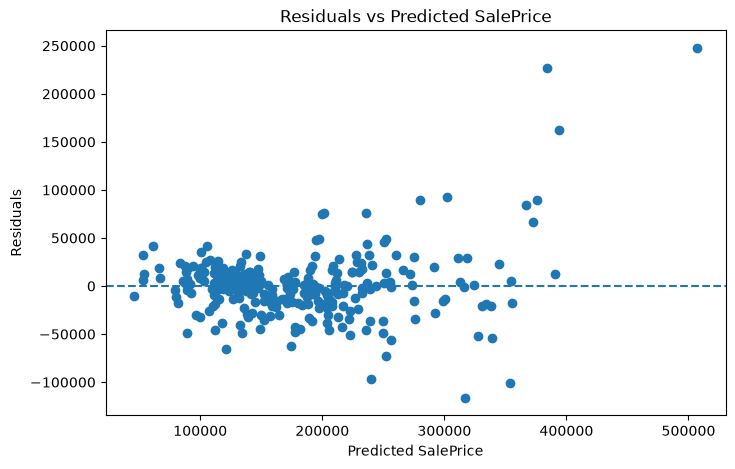

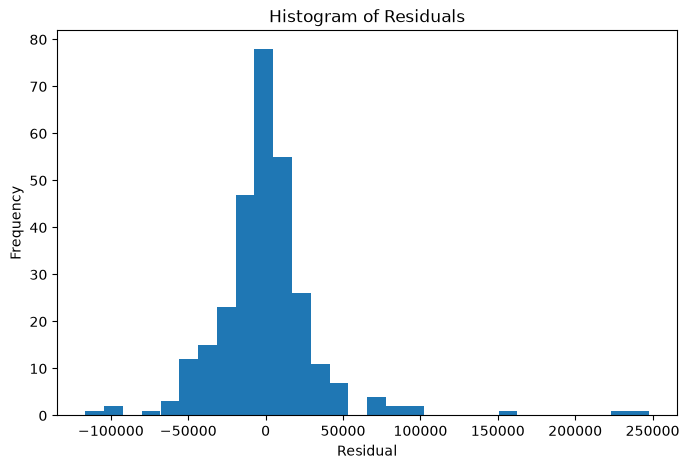

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted SalePrice")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

### Task 11 Interpretation

The residuals represent the differences between the actual and predicted house prices. Ideally, the residuals should be scattered around zero without a clear pattern. A strong pattern or systematic shape may indicate that the Linear Regression model is not capturing some relationships in the data. The histogram shows the distribution of the prediction errors.

## Task 12: Calculate MAE, MSE, RMSE, and R²

Four regression metrics are calculated on the test data:

- MAE (Mean Absolute Error)
- MSE (Mean Squared Error)
- RMSE (Root Mean Squared Error)
- R² (R-squared)

These metrics provide different ways to measure how closely the predicted prices match the actual prices.

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate regression metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Create metrics table
metrics_table = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Value': [mae, mse, rmse, r2]
})

display(metrics_table)

,Metric,Value
0,MAE,2.126220e+04
1,MSE,1.230844e+09
2,RMSE,3.508338e+04
3,R²,8.395318e-01


### Task 12 Interpretation

The metrics summarize the performance of the Linear Regression model on unseen test data. MAE and RMSE are expressed in the same general units as house prices, while MSE uses squared units. R² represents the proportion of variation in `SalePrice` explained by the model on the test set.

## Task 13: Explain the Regression Metrics

### MAE — Mean Absolute Error

MAE is the average absolute difference between the actual and predicted house prices. Lower MAE indicates smaller average prediction errors.

### MSE — Mean Squared Error

MSE is the average of the squared prediction errors. Larger errors receive more penalty because the errors are squared. Lower MSE indicates better performance.

### RMSE — Root Mean Squared Error

RMSE is the square root of MSE. It is useful because it is expressed in the same units as `SalePrice`. Lower RMSE indicates smaller prediction errors.

### R² — R-squared

R² measures how much of the variation in `SalePrice` is explained by the model. A higher R² generally indicates that the model explains more variation in the target variable.

### Metric for a Nontechnical Stakeholder

MAE is easy to explain to a nontechnical stakeholder because it represents the average absolute prediction error in the same general units as the house price. For example, it can be explained as the model being off by approximately a certain amount on average.

### Part 5 Conclusion

In this part, residuals were calculated and visualized using a residual plot and histogram. The residual analysis helps identify whether the model's errors are randomly distributed or show a pattern. MAE, MSE, RMSE, and R² were calculated to evaluate the model quantitatively. These metrics provide different information about the prediction errors and the amount of variation explained by the model. MAE is particularly easy to communicate because it represents the average absolute prediction error in the same general units as the target.

# Part 6: Training vs. Testing & Generalization

In this part, the Linear Regression model is evaluated on both the training and testing datasets. The results are compared to understand how well the model generalizes to unseen data and whether there is a noticeable difference between training and testing performance.

## Task 14: Calculate Training and Testing Metrics

The trained model is used to generate predictions for both the training and testing datasets. MAE, MSE, RMSE, and R² are then calculated for both sets and displayed side by side.

In [ ]:
y_train_pred = model.predict(X_train)

train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

test_mae = mean_absolute_error(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred)

performance_table = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Training': [train_mae, train_mse, train_rmse, train_r2],
    'Testing': [test_mae, test_mse, test_rmse, test_r2]
})

display(performance_table)

,Metric,Training,Testing
0,MAE,2.062546e+04,2.126220e+04
1,MSE,1.050206e+09,1.230844e+09
2,RMSE,3.240689e+04,3.508338e+04
3,R²,8.239253e-01,8.395318e-01


### Task 14 Interpretation

The table compares the model's performance on the training and testing datasets. Training metrics show how well the model fits the data used to train it, while testing metrics show how well it performs on unseen data. Comparing these values helps evaluate the model's generalization ability.

## Task 15: Train/Test Gap and Generalization

The difference between training and testing performance is examined to identify possible overfitting and assess the model's ability to generalize to unseen data.

If the training performance is much better than the testing performance, this may indicate overfitting. If training and testing performance are reasonably similar, the model is showing more consistent generalization.

### Answer

The training and testing performance is relatively close. The training MAE is 20,625.46 compared with a testing MAE of 21,262.20, while the training RMSE is 32,406.89 compared with a testing RMSE of 35,083.38. The R² values are also similar, with 0.8239 on the training set and 0.8395 on the testing set. Therefore, there is no large train/test performance gap in this experiment. The results do not show strong evidence of overfitting because the testing performance is reasonably close to the training performance.

### Part 6 Conclusion

In this part, the Linear Regression model was evaluated on both training and testing data. The MAE, MSE, RMSE, and R² values were compared side by side. This comparison helps determine whether the model performs consistently on unseen data. The difference between training and testing performance provides an indication of the model's generalization and possible overfitting.

# Part 7: Final Model Analysis & Conclusion

In this final part, the Linear Regression model is analyzed using the coefficient table and performance results. Important features, model limitations, and possible improvements are discussed. Finally, the trained model is applied to the Kaggle test dataset to create the required `submission.csv` file.

## Task 16: Identify 2–3 Influential Features

The coefficient table from Part 4 is examined to identify features with relatively large coefficient magnitudes. These features may have a stronger association with the predicted `SalePrice`.

Coefficient magnitude should be interpreted carefully because features may use different scales and units.

In [ ]:
influential_features = coefficient_table.copy()

influential_features['Absolute Coefficient'] = (
    influential_features['Coefficient'].abs()
)

influential_features = influential_features.sort_values(
    'Absolute Coefficient',
    ascending=False
)

display(
    influential_features[
        ['Feature', 'Coefficient', 'Absolute Coefficient']
    ].head(10)
)

,Feature,Coefficient,Absolute Coefficient
23,Neighborhood_NoRidge,77229.384646,77229.384646
30,Neighborhood_StoneBr,64592.847903,64592.847903
32,Neighborhood_Veenker,58542.485263,58542.485263
24,Neighborhood_NridgHt,58447.167820,58447.167820
12,Neighborhood_ClearCr,54203.183078,54203.183078
42,KitchenQual_TA,-53435.141738,53435.141738
40,KitchenQual_Fa,-52584.611941,52584.611941
14,Neighborhood_Crawfor,47692.948976,47692.948976
41,KitchenQual_Gd,-44295.223525,44295.223525
31,Neighborhood_Timber,37770.219866,37770.219866


### Task 16 Interpretation

Based on the absolute coefficient values, `Neighborhood_NoRidge`, `Neighborhood_StoneBr`, and `Neighborhood_Veenker` have the largest coefficient magnitudes in this model. These coefficients indicate relatively strong associations with predicted `SalePrice` compared with the other encoded features. However, coefficient magnitudes should be interpreted carefully because numerical and categorical features use different scales, so a larger coefficient does not automatically mean that a feature is more important in the real world.

## Task 17: Final Model Interpretation

The following points summarize the performance and limitations of the Linear Regression model.

- The model predicts house prices using the selected numerical and categorical features.
- Test-set MAE, MSE, RMSE, and R² were used to evaluate performance.
- MAE is useful for communicating the average prediction error because it is easy to understand.
- Features with relatively large coefficient magnitudes show stronger associations within this model.
- The model is limited by the small selected feature set and the assumptions of Linear Regression.
- The model may not capture complex nonlinear relationships between house characteristics and price.
- Additional features, better preprocessing, or more advanced models could be explored in future work.

### Final Interpretation

The Linear Regression model was trained to predict house `SalePrice` using selected numerical and categorical features. The model's performance was evaluated using MAE, MSE, RMSE, and R² on the test data. MAE is a useful metric for communicating prediction error because it represents the average absolute error in the same general units as house prices. The coefficient analysis identified features with relatively large coefficient magnitudes and therefore stronger associations within the model. However, coefficient magnitudes must be interpreted carefully because the features have different scales and units. One limitation is that the model uses a limited set of features and Linear Regression may not capture complex nonlinear relationships. Future improvements could include additional features, improved preprocessing, and comparison with other regression models.

## Task 18: Prepare `test.csv` and Create `submission.csv`

The same feature selection and one-hot encoding used for the training data must be applied to `test.csv`. The trained Linear Regression model is then used to predict `SalePrice` for all houses in the Kaggle test dataset.

The final submission file must contain exactly two columns:

- `Id`
- `SalePrice`

In [ ]:
kaggle_test = pd.read_csv("test.csv")

X_kaggle = kaggle_test[features].copy()

X_kaggle = pd.get_dummies(
    X_kaggle,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

X_kaggle = X_kaggle.reindex(
    columns=X_train.columns,
    fill_value=0
)

X_kaggle = X_kaggle.fillna(X.median())

kaggle_predictions = model.predict(X_kaggle)

submission = pd.DataFrame({
    'Id': kaggle_test['Id'],
    'SalePrice': kaggle_predictions
})

submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully.")

display(submission.head())
print("\nSubmission Shape:", submission.shape)

submission.csv created successfully.


,Id,SalePrice
0,1461,116937.836659
1,1462,160385.309459
2,1463,158629.892959
3,1464,180928.680933
4,1465,249563.175175



Submission Shape: (1459, 2)


### Task 18 Interpretation

The Kaggle test dataset was prepared using the same selected features and encoding approach used for the training data. The trained Linear Regression model generated predictions for all houses in `test.csv`. The resulting `submission.csv` contains the required `Id` and `SalePrice` columns and is ready for submission to Kaggle.

## Task 19: Submit `submission.csv` to Kaggle


### Kaggle Submission Result

**Public Leaderboard Score:** 0.16955

**Rank:** 3005

The `submission.csv` file was successfully submitted to the Kaggle House Prices competition. Kaggle processed the submission successfully and returned a public leaderboard score of 0.16955.

### Part 7 Conclusion

The Linear Regression model was analyzed using its coefficients, residual performance, and train/test metrics. The coefficient analysis provided information about the features associated with predicted house prices. The model has limitations because it uses a selected feature set and Linear Regression may not capture complex nonlinear relationships. The trained model was also applied to the Kaggle test dataset. Finally, a `submission.csv` file containing `Id` and `SalePrice` was created for Kaggle submission.